<a href="https://colab.research.google.com/github/fatehirfan1/depression-prediction-using-questionnaire-Machine-learning/blob/main/Depression_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== MODEL COMPARISON (Optimized) =====


,Model,MAE,RMSE,R2
0,Linear Regression,0.705061,1.209678,0.794055
1,Random Forest,1.227260,1.707773,0.589539
2,SVR (SVM),0.608568,1.138236,0.817662
3,Gradient Boosting,1.051020,1.454305,0.702338


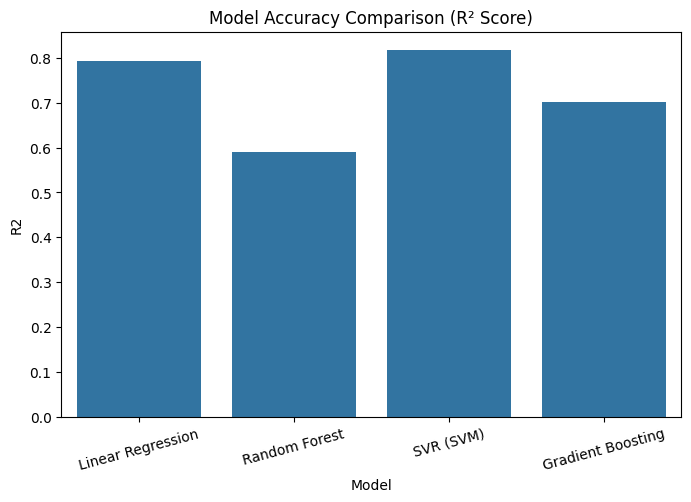


Most Impactful Feature: Feature       num__Stress Level
Importance             0.379785
Name: 1, dtype: object
Least Impactful Feature: Feature       cat__How often do you feel low energy or fatig...
Importance                                             0.000082
Name: 18, dtype: object


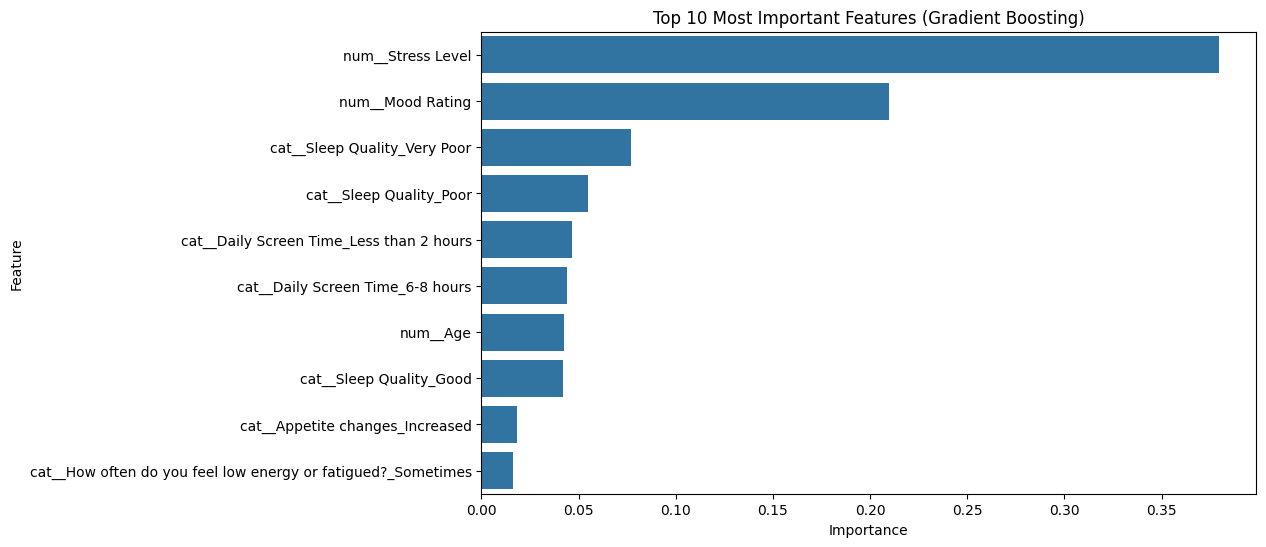


Sample Predicted Depression Score (Best Model): 7.841218968905817


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -------------------- LOAD DATASET --------------------
df = pd.read_csv("Depression Prediction.csv")
df.columns = df.columns.str.strip()

df.drop(columns=["Timestamp", "Name"], inplace=True)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df.fillna(df.mean(numeric_only=True), inplace=True)

# -------------------- FEATURES --------------------
categorical_cols = [
    "Gender",
    "Sleep Quality",
    "Daily Screen Time",
    "Physical Activity Level",
    "Appetite changes",
    "How often do you feel low energy or fatigued?"
]

numeric_cols = [
    "Age",
    "Stress Level",
    "Mood Rating"
]

X = df.drop("score", axis=1)
y = df["score"]

# -------------------- PREPROCESSOR --------------------
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
])

# -------------------- TRAIN TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ======================================================
# MODEL 1: LINEAR REGRESSION
# ======================================================
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)


# ======================================================
# MODEL 2: RANDOM FOREST (TUNED)
# ======================================================
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 4]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring="r2", n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)


# ======================================================
# MODEL 3: SUPPORT VECTOR REGRESSOR (TUNED)
# ======================================================
svr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", SVR())
])

svr_param_grid = {
    "model__C": [10, 50, 100],
    "model__gamma": ["scale", 0.05, 0.01],
    "model__epsilon": [0.1, 0.2]
}

svr_grid = GridSearchCV(svr_pipeline, svr_param_grid, cv=5, scoring="r2", n_jobs=-1)
svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_
y_pred_svr = best_svr.predict(X_test)


# ======================================================
# MODEL 4: GRADIENT BOOSTING (STRONG MODEL)
# ======================================================
gbr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gbr_param_grid = {
    "model__n_estimators": [150, 250],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gbr_grid = GridSearchCV(gbr_pipeline, gbr_param_grid, cv=5, scoring="r2", n_jobs=-1)
gbr_grid.fit(X_train, y_train)

best_gbr = gbr_grid.best_estimator_
y_pred_gbr = best_gbr.predict(X_test)


# ======================================================
# EVALUATION
# ======================================================
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = pd.DataFrame([
    {"Model": "Linear Regression", **evaluate(y_test, y_pred_lr)},
    {"Model": "Random Forest", **evaluate(y_test, y_pred_rf)},
    {"Model": "SVR (SVM)", **evaluate(y_test, y_pred_svr)},
    {"Model": "Gradient Boosting", **evaluate(y_test, y_pred_gbr)}
])

print("\n===== MODEL COMPARISON (Optimized) =====")
display(results)


# ======================================================
# VISUALIZATION
# ======================================================
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="R2", data=results)
plt.title("Model Accuracy Comparison (R² Score)")
plt.xticks(rotation=15)
plt.show()


# ======================================================
# FEATURE IMPORTANCE (FROM GRADIENT BOOSTING)
# ======================================================
feature_names = best_gbr.named_steps["prep"].get_feature_names_out()
importances = best_gbr.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nMost Impactful Feature:", feat_imp.iloc[0])
print("Least Impactful Feature:", feat_imp.iloc[-1])

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10))
plt.title("Top 10 Most Important Features (Gradient Boosting)")
plt.show()


# ======================================================
# SAMPLE PREDICTION
# ======================================================
sample = X.iloc[[0]]
predicted_score = best_gbr.predict(sample)
print("\nSample Predicted Depression Score (Best Model):", predicted_score[0])


In [ ]:
print("\n--- Depression Assessment Questionnaire ---")

# -------------------- Collect User Inputs --------------------
age = int(input("Enter your age: "))

gender = input("Gender (Male/Female): ").strip().title()
sleep_quality = input("Sleep Quality (Poor/Average/Good): ").strip().title()

stress = int(input("Stress Level (1 = Low, 5 = High): "))
mood = int(input("Mood Rating (1 = Very Low, 5 = Very Good): "))

screen_time = input("Daily Screen Time (2-4 hours / 4-6 hours / 6-8 hours): ").strip()
activity = input("Physical Activity (Never / 1-2 days/week / 3-4 days/week / Everyday): ").strip()
appetite = input("Appetite Changes (Increased / Decreased): ").strip().title()

fatigue = input("Low Energy/Fatigue (Rarely / Sometimes / Often): ").strip().title()


# -------------------- Create DataFrame (NO manual encoding) --------------------
user_data = pd.DataFrame([{
    "Age": age,
    "Gender": gender,
    "Sleep Quality": sleep_quality,
    "Stress Level": stress,
    "Mood Rating": mood,
    "Daily Screen Time": screen_time,
    "Physical Activity Level": activity,
    "Appetite changes": appetite,
    "How often do you feel low energy or fatigued?": fatigue
}])


# -------------------- Predict Using Best Model --------------------
predicted_score = best_gbr.predict(user_data)[0]   # or best_svr / best_rf

print("\nPredicted Depression Score:", round(predicted_score, 2))


# -------------------- Interpret Result --------------------
if predicted_score < 4:
    level = "No Depression"
elif predicted_score < 6:
    level = "Mild Depression"
elif predicted_score < 8:
    level = "Moderate Depression"
else:
    level = "Severe Depression"

print("Depression Level:", level)



--- Depression Assessment Questionnaire ---
Enter your age: 21
Gender (Male/Female): Male
Sleep Quality (Poor/Average/Good): Poor
Stress Level (1 = Low, 5 = High): 1
Mood Rating (1 = Very Low, 5 = Very Good): 1
Daily Screen Time (2-4 hours / 4-6 hours / 6-8 hours): 4-6 hours
Physical Activity (Never / 1-2 days/week / 3-4 days/week / Everyday): Everyday
Appetite Changes (Increased / Decreased): Increased
Low Energy/Fatigue (Rarely / Sometimes / Often): Sometimes

Predicted Depression Score: 9.37
Depression Level: Severe Depression
